In [35]:
# import useful libraries
import os #fornisce funzioni per interagire con il sistema operativo
import glob #trova file con pattern specifici, tipo cerca tutti i file .jpg
import numpy as np #per il calcolo numerico
import pandas as pd #per manipolare dati tabulari tipo exel
import matplotlib.pyplot as plt #per creare e grafici e visualizzazioni di dati
import scipy.io as sio # useful because ground truth labels are uploaded as .mat files
import cv2 # per cariche e processare le immagini
import matplotlib.patches as patches #per disegnare forme sopra le immagini
from PIL import Image

In [36]:
# CONTROLLO SE NUMERO MASCHERE E IMMAGINI COINCIDONO
%pwd

DATA_PATH = 'data/raw/pannuke'

os.listdir(DATA_PATH)

image_paths = glob.glob(os.path.join(DATA_PATH, "train", "images", "*.png*")) \
             + glob.glob(os.path.join(DATA_PATH, "validate", "images", "*.png*"))
mask_paths = glob.glob(os.path.join(DATA_PATH, "train", "masks", "*.png")) \
           + glob.glob(os.path.join(DATA_PATH, "validate", "masks", "*.png"))


print(len(image_paths))
print(len(mask_paths))

7901
7901


In [37]:
# CONTROLLO SE MASCHERE BINARIE
# 1. maschera di esempio (1-10.png)

percorso_test = mask_paths[2]
maschera = cv2.imread(percorso_test, cv2.IMREAD_UNCHANGED)

# 2. conotrollo valori unici
valori = np.unique(maschera)

print("--- ESITO DEL TEST ---")
print(f"I valori presenti nella maschera sono: {valori}")

# 3. Interpretazione automatica
if len(valori) == 2:
    print("Confermato: Il dataset è BINARIO (solo sfondo e nuclei).")
else:
    print(f"Il dataset è MULTICLASSE (contiene {len(valori)} tipi di etichette).") 

--- ESITO DEL TEST ---
I valori presenti nella maschera sono: [  0 255]
Confermato: Il dataset è BINARIO (solo sfondo e nuclei).


In [38]:
# FUNZIONE UTILE PER ESTRARRE DATI DALLE IMMAGINI

def load_labels_from_png(mask_path):
    #Estrae metadati (inst_map, bboxes, centroids) da una maschera PNG binaria. crea una carta d'identità digitale per ogni singolo nucleo
    #IMREAD_GRAYSCALE serve a caricare l'immagine in scala di grigi.
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    num_labels, inst_map, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)
    # SPIEGAZIONE DEI 4 RISULTATI:
    # 1. num_labels: Un numero intero(numero nuclei +1 (che è lo sfondo che ha indice 0)). Se trova 4 nuclei, sarà 5 (perché conta anche lo sfondo!).
    # 2. inst_map: Una matrice grande come l'immagine originale. Sfondo: Il computer inizia a leggere e vede il nero. Dice: "Ok, questo è lo 0". 
        #Primo Nucleo: Incontra la prima macchia bianca. Dice: "Tutti i pixel di questa macchia d'ora in poi si chiameranno 1".
        #Secondo Nucleo: Prosegue e trova un'altra macchia separata. Dice: "Questi pixel non sono attaccati all'1, quindi sono un nuovo oggetto. Li chiamerò 2"
        #np.where(inst_map == 2),  restituirà solo ed esclusivamente le coordinate del secondo nucleo
    # 3. stats: Una tabella con 5 colonne per ogni oggetto (x, y, larghezza, altezza, area). 
        #C'è un collegamento perfetto e biunivoco (uno a uno) tra il numero del nucleo e la riga della tabella stats
        #Se nella inst_map vedi un gruppo di pixel con il numero 2, tutte le informazioni fisiche di quel gruppo si trovano nella riga 2 della tabella stats
    # 4. centroids: Una tabella con le coordinate (x, y) del centro esatto di ogni oggetto.

    #lista per i nuclei, es. np.arrange(1, 5): [1, 2, 3, 4]
    nuclei_id = np.arange(1, num_labels) 
   
        # array di "1" lungo quanto la lista dei nuclei (dataset binario, classe nuclei=1)
    classes = np.ones(len(nuclei_id), dtype=int)


    #Calcolo delle Bounding Boxes (Rettangoli)
    #da [x, y, larghezza, altezza] a [x_min, y_min, x_max, y_max].

    bboxes = []
    for i in range(1, num_labels): # no 0
        x_min, y_min, width, height, area = stats[i]
        # Calcoliamo il punto d'angolo opposto
        x_max = x_min + width
        y_max = y_min + height
        # Aggiungiamo i 4 numeri alla nostra lista
        bboxes.append([x_min, y_min, x_max, y_max]) 
        # lista in una matrice NumPy (array) -> più veloce per i calcoli
    bboxes = np.array(bboxes)
# Pulizia dei Centroidi (centroids ha anche il centro dell'immagine, togliamo)
    final_centroids = centroids[1:]

#Creazione del Dizionario e INVIO (Return) ---
    dict_labels = {
        'inst_map': inst_map,         # La matrice con i numeri ID
        'nuclei_id': nuclei_id,       # La lista [1, 2, 3...]
        'classes': classes,           # La lista [1, 1, 1...]
        'bboxs': bboxes,              # I rettangoli [x_min, y_min, x_max, y_max]
        'centroids': final_centroids  # I punti centrali (x, y)
    }
    
    return dict_labels

In [39]:
# VERIFICA NUCLEI TORVATI NELLA PRIMA IMMAGINE
percorso_della_mia_maschera = mask_paths[0] 

label = load_labels_from_png(percorso_della_mia_maschera)
print("Informazioni disponibili:", label.keys()) 
# Estrai la matrice dei centroidi
centroids = label['centroids']

# Verifica quanti nuclei sono stati trovati
print(f"Numero di nuclei rilevati: {len(centroids)}") 



Informazioni disponibili: dict_keys(['inst_map', 'nuclei_id', 'classes', 'bboxs', 'centroids'])
Numero di nuclei rilevati: 14


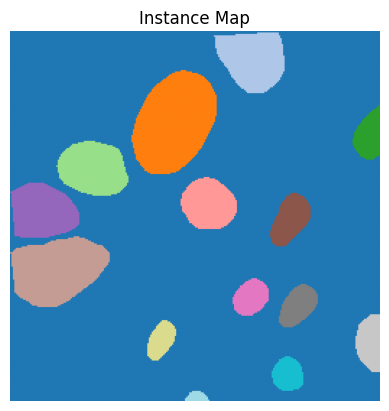

In [40]:
# ESEMPIO INSTANCE MASK, mappa colori categorica
inst_map = label['inst_map'] 
bboxs = label['bboxs']
nuclei_id = label['nuclei_id']
centroids = label['centroids']
classes = label ['classes']
# variabili singole più facili da manipolare

plt.imshow(inst_map, cmap="tab20") 
plt.title("Instance Map") 
plt.axis("off") 
plt.show() 

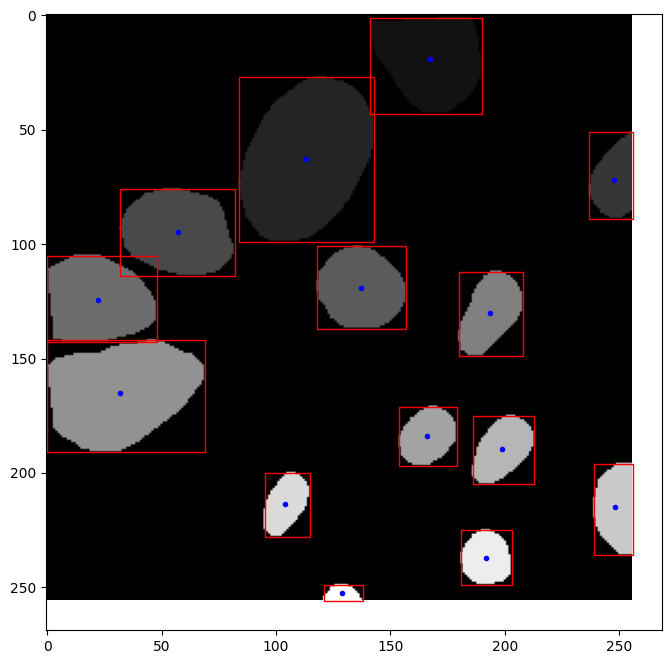

In [41]:
# 2. GRAFICO BOUNDING BOXES E CENTROIDS
fig, ax = plt.subplots(figsize=(8,8)) 
ax.imshow(inst_map, cmap="gray") #Carica la mappa dei nuclei come sfondo (GRIGIO)
for idx, nucleus_id in enumerate(nuclei_id): 
    x1, y1, x2, y2 = bboxs[idx] 
    cx, cy = centroids[idx]  
    width = x2 - x1
    height = y2 - y1
    rect = patches.Rectangle((x1, y1), width, height,
                             linewidth=1, edgecolor="r", facecolor="none") 
    # la funzione rect in input riceve rispettivamente (punto di partenza, larghezza (x2-x1) e altezza (y2-y1)) 
    #edgecolor="r": r sta per Red (Rosso). Disegna il contorno.
    #facecolor="none" dice di non colorare l'interno del rettangolo
    ax.add_patch(rect)

    ax.plot(cx, cy, "bo", markersize=3) #bo": Sta per Blue Object ( cerchietto blu). ## densità nuclei

plt.show()



In [46]:
# NUMERI TOTALI NUCLEI E MEDIA NUCLEI PER IMMAGINE
nuclei_counts=[]

#loop su ogni maschera
for mask_path in mask_paths:
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)  # carica in scala di grigi

    # conta i nuclei
    num_labels, _ = cv2.connectedComponents(mask)
    # Il numero di nuclei è num_labels meno 1 (lo sfondo)
    n_nuclei = num_labels - 1
    
    # 3. Aggiungiamo il numero alla lista
    nuclei_counts.append(n_nuclei)
# 3. Risultati finali
totale_nuclei_dataset = sum(nuclei_counts)
media_nuclei_dataset = np.mean(nuclei_counts) #funzione della libreria NumPy che serve a calcolare la media aritmetica dei numeri contenuti in una lista o in un array
print(f"Nuclei totali nel dataset:", totale_nuclei_dataset)
print(f"Media di nuclei per immagine: {media_nuclei_dataset:.2f}") 


Nuclei totali nel dataset: 160803
Media di nuclei per immagine: 20.35


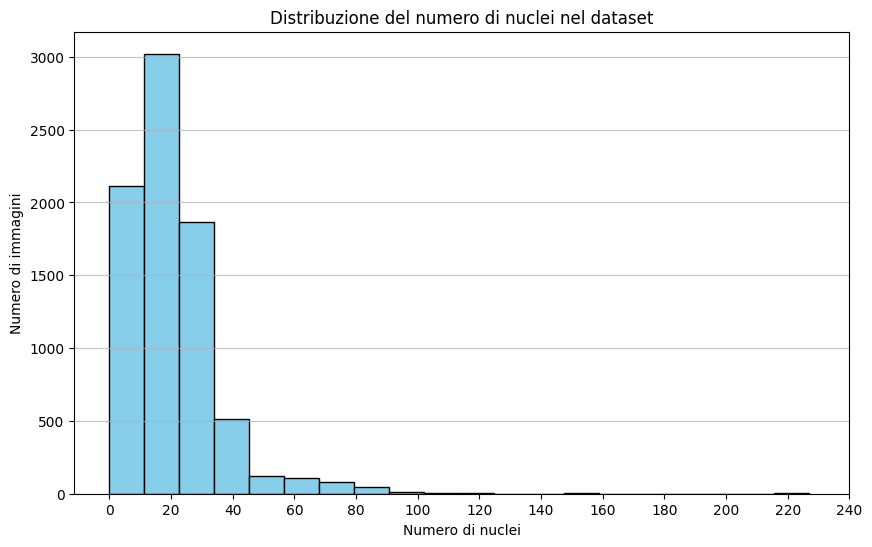

In [47]:
# GRAFICO DISTRIBUZIONE NUCLEI NELLE IMMAGINI

plt.figure(figsize=(10, 6))
plt.hist(conteggio_nuclei, bins=20, color='skyblue', edgecolor='black')
plt.title('Distribuzione del numero di nuclei nel dataset')
plt.xlabel('Numero di nuclei')
plt.ylabel('Numero di immagini')
plt.xticks(np.arange(0, max(conteggio_nuclei) + 20, 20))
plt.grid(axis='y', alpha=0.75)
plt.show() 

In [48]:
# DENSITà MEDIA E DEVIAzIONE STANDARD
nuclei_counts = []

for mask_path in mask_paths:
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)  # carica in scala di grigi
    _, binary = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)  # binarizza
    num_labels, _ = cv2.connectedComponents(binary)
    nuclei_counts.append(num_labels - 1)  # sottrai 1 perché 0 = sfondo

densities = []

for mask_path, count in zip(mask_paths, nuclei_counts):
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    area = mask.shape[0] * mask.shape[1]  # numero totale di pixel
    density = count / area
    densities.append(density)
    count_nuclei = count

# media e deviazione standard
import numpy as np
print("Densità media:", np.mean(densities))
print("Deviazione standard:", np.std(densities))
print("numero di nuclei:", np.mean(count_nuclei))

Densità media: 0.00031055044394597995
Deviazione standard: 0.0002340104048383712
numero di nuclei: 21.0


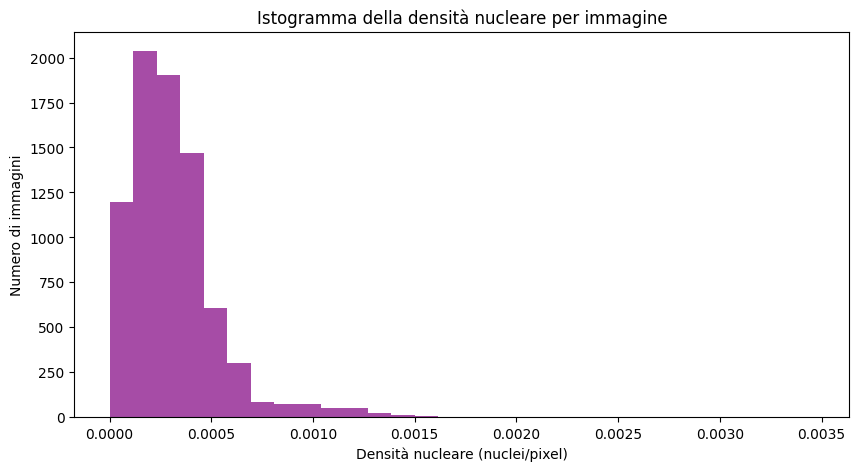

In [30]:
# ISOGRAMMA DENSITà NUCLEARE (NUCLEO/PIXEL)

plt.figure(figsize=(10,5))
plt.hist(densities, bins=30, color='purple', alpha=0.7)
plt.title("Istogramma della densità nucleare per immagine")
plt.xlabel("Densità nucleare (nuclei/pixel)")
plt.ylabel("Numero di immagini")
plt.show()

 TRAIN set:
Numero nuclei per immagine (prime 10): [14, 28, 4, 10, 20, 9, 12, 25, 21, 27]
Densità media: 0.0003109307712284563
Deviazione standard: 0.000235527727288374

 VALIDATE set:
Numero nuclei per immagine (prime 10): [24, 13, 10, 29, 8, 24, 28, 18, 27, 16]
Densità media: 0.000308394935060654
Deviazione standard: 0.0002252057683431414


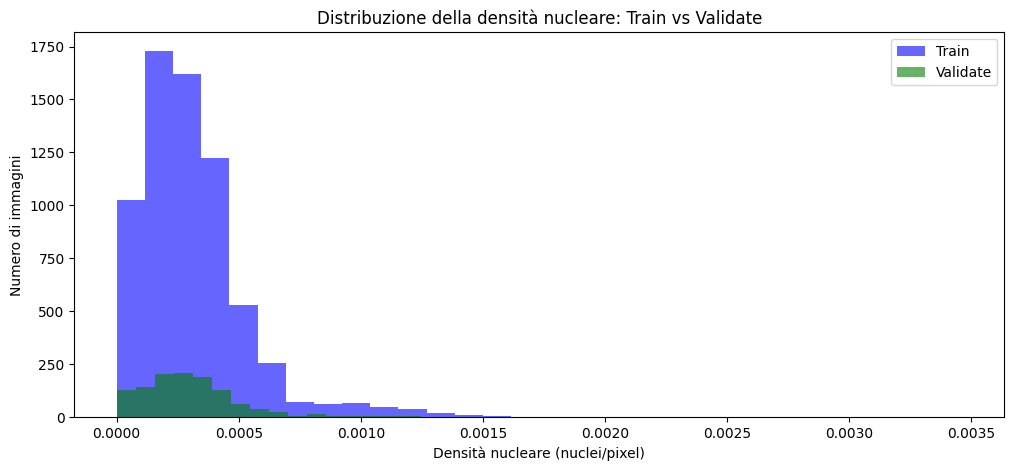

In [31]:
# Analisi separata TRAIN vs VALIDATE in base alla densità

train_masks = os.path.join(DATA_PATH, "train", "masks")
validate_masks = os.path.join(DATA_PATH, "validate", "masks")

def analyze_masks(mask_folder):
    mask_paths = glob.glob(os.path.join(mask_folder, "*.png"))
    nuclei_counts = []
    densities = []
    for mask_path in mask_paths:
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        _, binary = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
        num_labels, _ = cv2.connectedComponents(binary)
        nuclei_counts.append(num_labels - 1)
        area = mask.shape[0] * mask.shape[1]
        densities.append((num_labels - 1) / area)
    return nuclei_counts, densities

train_counts, train_densities = analyze_masks(train_masks)
validate_counts, validate_densities = analyze_masks(validate_masks)

print(" TRAIN set:")
print("Numero nuclei per immagine (prime 10):", train_counts[:10])
print("Densità media:", np.mean(train_densities))
print("Deviazione standard:", np.std(train_densities))

print("\n VALIDATE set:")
print("Numero nuclei per immagine (prime 10):", validate_counts[:10])
print("Densità media:", np.mean(validate_densities))
print("Deviazione standard:", np.std(validate_densities))

# Istogramma comparativo
plt.figure(figsize=(12,5))
plt.hist(train_densities, bins=30, alpha=0.6, label='Train', color='blue')
plt.hist(validate_densities, bins=30, alpha=0.6, label='Validate', color='green')
plt.title("Distribuzione della densità nucleare: Train vs Validate")
plt.xlabel("Densità nucleare (nuclei/pixel)")
plt.ylabel("Numero di immagini")
plt.legend()
plt.show()

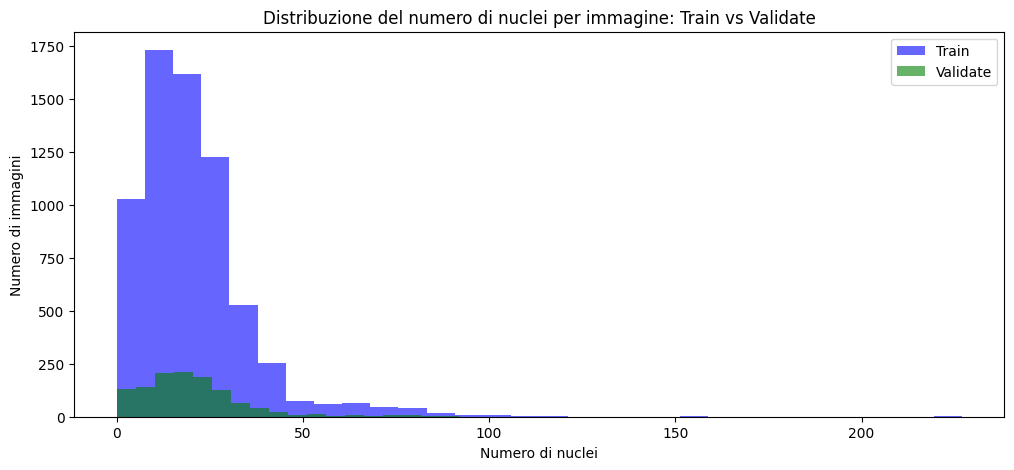

TRAIN:
Media nuclei: 20.377159023228113
Deviazione standard: 15.435545135570878

 VALIDATE:
Media nuclei: 20.21097046413502
Deviazione standard: 14.759085234136116


In [33]:
# Analisi separata TRAIN vs VALIDATE IN BASE AL NUMERO DI NUCLEI


plt.figure(figsize=(12,5))

plt.hist(train_counts, bins=30, alpha=0.6, label='Train', color='blue')
plt.hist(validate_counts, bins=30, alpha=0.6, label='Validate', color='green')

plt.title("Distribuzione del numero di nuclei per immagine: Train vs Validate")
plt.xlabel("Numero di nuclei")
plt.ylabel("Numero di immagini")
plt.legend()

plt.show()

# ----------------------------------------
# Statistiche
print("TRAIN:")
print("Media nuclei:", np.mean(train_counts))
print("Deviazione standard:", np.std(train_counts))

print("\n VALIDATE:")
print("Media nuclei:", np.mean(validate_counts))
print("Deviazione standard:", np.std(validate_counts))

(array([0.02151071, 0.02349632, 0.03392074, 0.03491354, 0.03127327,
        0.02101431, 0.01042442, 0.00661868, 0.00380574, 0.00132374,
        0.00215107, 0.00066187, 0.0009928 , 0.00066187, 0.0009928 ,
        0.0009928 , 0.0004964 , 0.00033093, 0.        , 0.00016547,
        0.00016547, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.00016547]),
 array([  0. ,   5.1,  10.2,  15.3,  20.4,  25.5,  30.6,  35.7,  40.8,
         45.9,  51. ,  56.1,  61.2,  66.3,  71.4,  76.5,  81.6,  86.7,
         91.8,  96.9, 102. , 107.1, 112.2, 117.3, 122.4, 127.5, 132.6,
        137.7, 142.8, 147.9, 153. ]),
 <BarContainer object of 30 artists>)

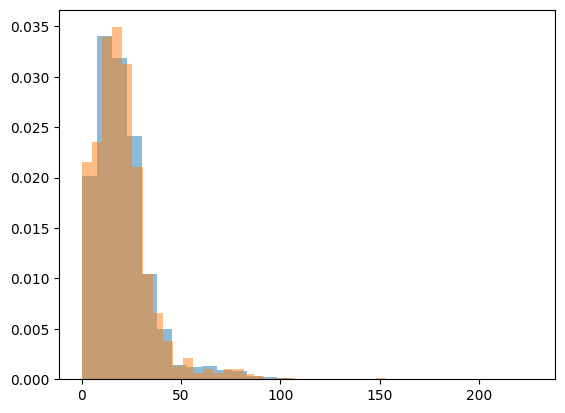

In [34]:
# CONFRONTO NORMALIZZATO 
plt.hist(train_counts, bins=30, alpha=0.5, density=True, label='Train')
plt.hist(validate_counts, bins=30, alpha=0.5, density=True, label='Validate')

In [14]:
# ANALISI RGB
image_paths = glob.glob(os.path.join(DATA_PATH, "train", "images", "*.png*")) \
             + glob.glob(os.path.join(DATA_PATH, "validate", "images", "*.png*"))

# array vuoti per ogni canale
R_values = []
G_values = []
B_values = []

# loop su tutte le immagini
for img_path in image_paths:
    img = Image.open(img_path)          # apri immagine
    img = np.array(img)                  # conversione in array numpy
    if img.ndim == 3:                    # RGB
        R_values.extend(img[:,:,0].flatten()[::10])
        G_values.extend(img[:,:,1].flatten()[::10])
        B_values.extend(img[:,:,2].flatten()[::10])

# ----------------------------------------
# Statistiche RGB

R_mean = np.mean(R_values)
G_mean = np.mean(G_values)
B_mean = np.mean(B_values)

R_std = np.std(R_values)
G_std = np.std(G_values)
B_std = np.std(B_values)

print("📊 STATISTICHE RGB\n")

print("🔴 Red  -> Media:", R_mean, " | Deviazione standard:", R_std)
print("🟢 Green-> Media:", G_mean, " | Deviazione standard:", G_std)
print("🔵 Blue -> Media:", B_mean, " | Deviazione standard:", B_std)

📊 STATISTICHE RGB

🔴 Red  -> Media: 179.7224422637524  | Deviazione standard: 45.56574914485882
🟢 Green-> Media: 146.19555637727282  | Deviazione standard: 57.61881858380247
🔵 Blue -> Media: 189.04579402405656  | Deviazione standard: 48.527831951085695


                  R             G             B
count  5.178315e+07  5.178315e+07  5.178315e+07
mean   1.797224e+02  1.461956e+02  1.890458e+02
std    4.556575e+01  5.761882e+01  4.852783e+01
min    0.000000e+00  0.000000e+00  0.000000e+00
25%    1.500000e+02  1.030000e+02  1.610000e+02
50%    1.840000e+02  1.470000e+02  2.000000e+02
75%    2.150000e+02  1.900000e+02  2.280000e+02
max    2.550000e+02  2.550000e+02  2.550000e+02


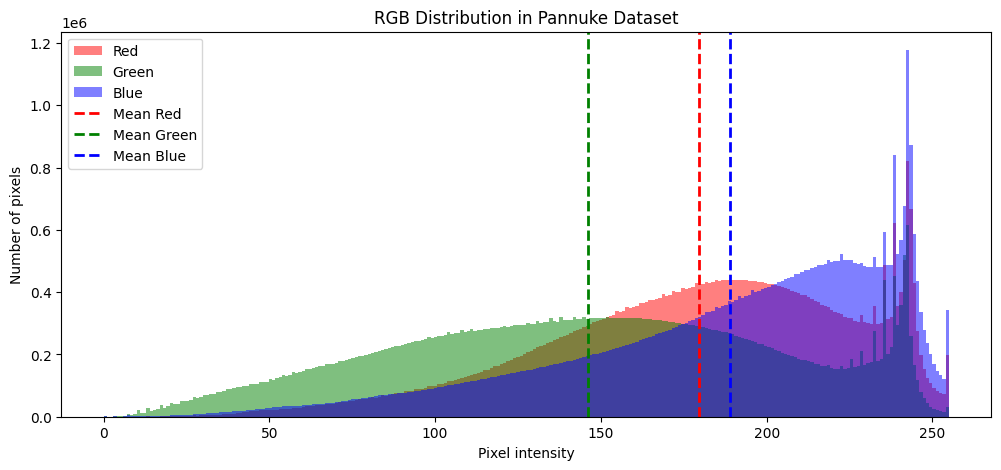

In [15]:
df = pd.DataFrame({
    'R': R_values,
    'G': G_values,
    'B': B_values
})

print(df.describe())

plt.figure(figsize=(12,5))

plt.hist(R_values, bins=256, color='red', alpha=0.5, label='Red')
plt.hist(G_values, bins=256, color='green', alpha=0.5, label='Green')
plt.hist(B_values, bins=256, color='blue', alpha=0.5, label='Blue')

plt.axvline(R_mean, color='red', linestyle='dashed', linewidth=2, label='Mean Red')
plt.axvline(G_mean, color='green', linestyle='dashed', linewidth=2, label='Mean Green')
plt.axvline(B_mean, color='blue', linestyle='dashed', linewidth=2, label='Mean Blue')


plt.title("RGB Distribution in Pannuke Dataset")
plt.xlabel("Pixel intensity")
plt.ylabel("Number of pixels")
plt.legend()
plt.show()